In [301]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [302]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [303]:
def Green(r, R):
    return np.log(R/r)/(2 * math.pi)

In [304]:
def pathGenerator(v, segments, g, f, eps = 0.001, maxSteps = 16, maxR = 10):
    x0 = v
    path = []
    source = 0
    for step in range(0, maxSteps): 
        path.append(x0)
        r = min([shortestDistance(x0, segments), maxR])
        if r < eps: 
            return path, g(x0) - source
        ### source term sample and record
        source_r = math.sqrt(random.uniform(0, 1)) * r
        source_theta = random.uniform(0, 2*math.pi)
        source_local = x0 + np.array([source_r * math.cos(source_theta), source_r * math.sin(source_theta)])
        source += r * r * f(source_local)/4
        
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
    return [], 0

In [305]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 1]]), np.array([[-1, 1], [1, 1]])]

#v = np.array([0, 0])
def boundary(v):
    return 2 * v[0] * v[0] + v[1] * v[1]

def source(v): 
    return 6

In [306]:
pathGenerator(np.array([0, 0]), segments, boundary, source)

([array([0, 0]),
  array([ 0.93938624, -0.34286076]),
  array([ 0.88063204, -0.35775952]),
  array([ 0.7922834 , -0.43802923]),
  array([ 0.97172437, -0.33340073]),
  array([ 0.97119234, -0.30513011]),
  array([ 0.97358148, -0.2764217 ]),
  array([ 0.99943977, -0.27100996])],
 0.4761117389595195)

In [307]:
target = []
width = range(1, 100)
height = range(1, 100)
for i in width:
    for j in height:
        target.append(np.array([i/50 - 1, j/50 - 1]))

print(len(target))

9801


In [308]:
paths = []
boundaries = []
maxPath = 0;
for v in target:
    p, b = pathGenerator(v, segments, boundary, source)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)
        if len(p) > maxPath:
            maxPath = len(p)


In [309]:
paths1 = np.zeros((len(paths), maxPath, 2))
maxPath -= 1
for i in range(len(paths)):
    path = paths[i]
    source = path[len(path) - 1].reshape(1,2)
    path = path[0: len(path) - 1]
    npath = np.array(path)
    if len(path) < maxPath:
        npath = np.concatenate((npath, np.ones((maxPath - len(path), 2)) * np.array(path[len(path) - 1])))

    paths1[i] = np.concatenate((npath, source))

print(paths1.shape)

(8204, 16, 2)


In [310]:
paths1[760]

array([[-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.82      ,  0.72      ],
       [-0.9997844 ,  0.72880733]])

In [311]:
paths1 = paths1.reshape(-1, 16, 2).astype("float32")
boundary1 = np.array(boundaries).astype("float32")

In [312]:
class NN(keras.Model):
    def __init__(self, units):
        super(NN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(3)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [313]:
class Ysolver1(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layer):
        super(Ysolver1, self).__init__()
        self.model = NN(layer)

        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path, training, batch):
        #print(path.shape)
        y_pred = self.model(path[:, 0], training)[:, 0]
        #print(y_pred.shape)
        for i in range(15): ###input path should be (-1, 2) shaped nparray, no len()
            #y = self.Ymodel(path[:, i], training)
            #print(y.shape)
            #z_input = tf.concat([path[:, i],y], 1)
            z = self.model(path[:, i], training)[:, 1:3] #obtain gradients for steps
            diff = path[:, i + 1] - path[:, i]
            #print(diff.shape)
            add = z[:, 0]*diff[:, 0] + z[:, 1]*diff[:, 1] #accumulating
            #print(add.shape)
            y_pred += add

        return y_pred

In [314]:
class NNsolver1(keras.Model):
    def __init__(self, paths, boundary):
        super(NNsolver1, self).__init__()
        self.paths = paths
        self.boundary = np.array(boundary)
        self.model = Ysolver1([32, 64, 128])
        self.optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=5e-4 , epsilon=1e-8)

    def loss_fn(self, y_pred, y):
        delta = y_pred - y
        loss = tf.reduce_mean(tf.square(delta))
        return loss

    def train_step(self, cur_path, training, batch_size):           
        return self.model(cur_path, training, batch_size)

    def train(self, batch_size): 
        training_history = []
        for i in range((len(self.paths) - 1)//batch_size + 1):
            batch = batch_size
            if (i + 1) * batch_size > len(paths):
                batch = len(paths) - i * batch_size
            cur_path = self.paths[i*batch_size: i*batch_size + batch]
            cur_bound = self.boundary[i*batch_size: i*batch_size + batch]
                
            with tf.GradientTape() as tape:
                y_pred = self.train_step(cur_path, training = True, batch_size=batch)
                loss = self.loss_fn(y_pred, cur_bound)

            training_vars = self.model.trainable_variables 
            grad = tape.gradient(loss, training_vars)
            #print(grad)
            #print("----------------------------------------------------")
            self.optimizer.apply_gradients(zip(grad, training_vars))
            #print(self.model.Ymodel.trainable_variables)
            training_history.append(loss)

        return training_history

    def train_epoch(self, epoch, batch_size):
        for i in range(epoch):
            cur_history = self.train(batch_size)
            print("epoch: " + str(i) + " loss: "+ str(np.mean(np.array(cur_history))))


In [315]:
training = NNsolver1(paths1, boundary1)
training.train_epoch(40, 256)

epoch: 0 loss: 1.9980878
epoch: 1 loss: 1.1309334
epoch: 2 loss: 0.83060706
epoch: 3 loss: 0.7067032
epoch: 4 loss: 0.5998262
epoch: 5 loss: 0.4948612
epoch: 6 loss: 0.3997433
epoch: 7 loss: 0.32338598
epoch: 8 loss: 0.269887
epoch: 9 loss: 0.23124523
epoch: 10 loss: 0.20118771
epoch: 11 loss: 0.17468627
epoch: 12 loss: 0.15273902
epoch: 13 loss: 0.13254744
epoch: 14 loss: 0.11762337
epoch: 15 loss: 0.104177125
epoch: 16 loss: 0.093339875
epoch: 17 loss: 0.08194194
epoch: 18 loss: 0.074251756
epoch: 19 loss: 0.067512065
epoch: 20 loss: 0.061445404
epoch: 21 loss: 0.05817843
epoch: 22 loss: 0.053168356
epoch: 23 loss: 0.050447915
epoch: 24 loss: 0.04842323
epoch: 25 loss: 0.04585174
epoch: 26 loss: 0.044268735
epoch: 27 loss: 0.04329524
epoch: 28 loss: 0.041377347
epoch: 29 loss: 0.0403047
epoch: 30 loss: 0.03929155
epoch: 31 loss: 0.038144093
epoch: 32 loss: 0.037139237
epoch: 33 loss: 0.03611501
epoch: 34 loss: 0.035166066
epoch: 35 loss: 0.034208048
epoch: 36 loss: 0.033380374
epoch:

In [316]:
width = range(101)
height = range(101)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/50 - 1)
        Y.append(j/50 - 1)
        Z.append(training.model.model(np.array([i/50 - 1 ,j/50 - 1]).reshape([1, 2]).astype("float32")))

X = np.array(X).reshape(101, 101)
Y = np.array(Y).reshape(101, 101)


In [317]:
Z2 = np.array(Z)[:, :, 0].reshape(101, 101)

(101, 101)


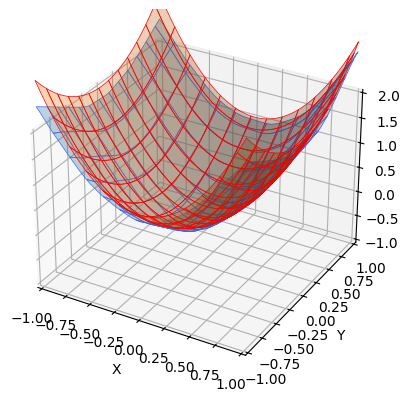

In [321]:
Z1 = Y*Y + 2 * X*X
print(Z1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 2),
       xlabel='X', ylabel='Y', zlabel='Z')

plt.show()

(101, 101)


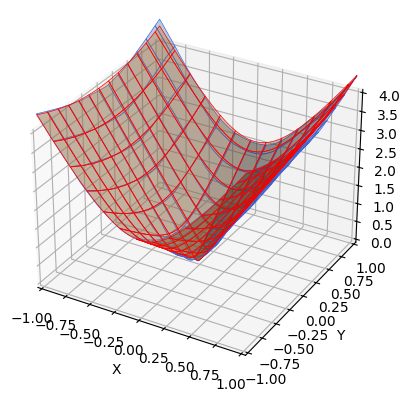

In [320]:
Z3 = np.linalg.norm(np.array(Z)[:, :, 1:3].reshape(-1, 2), axis = 1).reshape(101, 101)
Z1 = 2 * np.sqrt(4 * X*X + Y*Y)
print(Z1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z3, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 4),
       xlabel='X', ylabel='Y', zlabel='Z')

plt.show()